In [3]:
HVG_NUMBER=6349
hvg_number=HVG_NUMBER
k = 20 # number_of_neighbors
PROP_TO_SAMPLE=0.4


SAMPLE_COL = "sample_id"
ANNOTATION_COL = 'lvl5_annotation'
annotation_col = ANNOTATION_COL

DISEASE="both"
disease="both"

import scanpy as sc

from anndata import AnnData

import gc
import os
BASE_DIR = '/nfs/team298/ls34/new_disease_atlas/milopy_final/'
#os.listdir(BASE_DIR + '/model_A_scvi_6099_QueryREYNOLDS/')
#from scib_metrics.benchmark import Benchmarker, BatchCorrection, BioConservation
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

from collections import Counter
import datetime
import pickle
import seaborn as sns; sns.set()
import pandas as pd


from matplotlib.pyplot import rc_context
import matplotlib.patheffects as pe
import warnings
sc.settings.verbosity = 0
warnings.filterwarnings("ignore")

## r2py setup
import rpy2.rinterface_lib.callbacks
import logging
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)
%load_ext rpy2.ipython



# eczema + Ps

In [4]:
BASE_DIR +f'model_A_scvi_{HVG_NUMBER}_QueryREYNOLDS/'

'/nfs/team298/ls34/new_disease_atlas/milopy_final/model_A_scvi_6349_QueryREYNOLDS/'

In [5]:
processed=False

In [6]:
if processed:
    adata = sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_milo_calculated20k.h5ad')

else:
    adata = sc.read_h5ad(BASE_DIR +f'model_A_scvi_{HVG_NUMBER}_QueryREYNOLDS/adata_annotated_both.h5ad')
    adata = adata[adata.obs["Site_status"]=="Lesional"]
    RENAME={"Tnaive_CD8":"Tnaive"}
    adata.obs['lvl5_annotation']= adata.obs['lvl5_annotation'].map(RENAME).fillna( adata.obs['lvl5_annotation'])
    #adata = adata[adata.obs["dataset_id"]=="Reynolds"]
#    adata.obs["Patient_status"].value_counts()



In [7]:
adata.obs.dataset_id.value_counts()

dataset_id
Fiskin_AD        113239
Reynolds          92857
Luc_Psoriasis     51747
Ma_Psoriasis      41155
Name: count, dtype: int64

In [8]:
if not processed:
    sc.pp.neighbors(adata, n_neighbors=k, use_rep="X_scarches")
    rename={}
    for x in list(adata.obs[ANNOTATION_COL].unique()):
        if x.startswith("Mac") or x.startswith("Mig") or x.startswith("Mo") or x.startswith("cDC") or x.startswith("pDC")  or x.startswith("LC") or x.startswith("Eos") or x.startswith("Neu") or x.startswith("Mast") or x.startswith("Trans"):   
            rename[x] ='Myeloid'
        elif x.startswith("T") or x.startswith("T") or x.startswith("NK") or x.startswith("ILC"):  
            rename[x] = "T/ILC"
        elif x.startswith("V") or x.startswith("LE") or x.startswith("Peri"): 
            rename[x] = 'Endothelium/pericyte'
        elif x.startswith("KC_HF") or x.startswith("Swea") or x.startswith("Glan") or x.startswith("KC_Seb"): 
            rename[x] = "Keratinocyte_Appendage"
        elif x.startswith("KC") or x.startswith("Swea") or x.startswith("Glan"): 
            rename[x] = "Keratinocyte"
        elif x.startswith("F"):
            rename[x] = "Fibroblast"
    #     elif x.startswith("Bcell") or x.startswith("Plas"):
    #         rename[x] = "Bcell/plasma cell"
        else:
            print(x)
            rename[x] = "Other"
    adata.obs["lvl0_new"] =adata.obs[ANNOTATION_COL].map(rename)
    adata.obs["lvl0_new"] .value_counts()
    adata.write('/nfs/team298/ls34/adult_skin/final_adatas/adata_milo_calculated20k.h5ad')
else:
    rename={}
    for x in list(adata.obs[ANNOTATION_COL].unique()):
        if x.startswith("Mac") or x.startswith("Mig") or x.startswith("Mo") or x.startswith("cDC") or x.startswith("pDC")  or x.startswith("LC") or x.startswith("Eos") or x.startswith("Neu") or x.startswith("Mast") or x.startswith("Trans"):   
            rename[x] ='Myeloid'
        elif x.startswith("T") or x.startswith("T") or x.startswith("NK") or x.startswith("ILC"):  
            rename[x] = "T/ILC"
        elif x.startswith("V") or x.startswith("LE") or x.startswith("Peri"): 
            rename[x] = 'Endothelium/pericyte'
        elif x.startswith("KC_HF") or x.startswith("Swea") or x.startswith("Glan") or x.startswith("KC_Seb"): 
            rename[x] = "Keratinocyte_Appendage"
        elif x.startswith("KC") or x.startswith("Swea") or x.startswith("Glan"): 
            rename[x] = "Keratinocyte"
        elif x.startswith("F"):
            rename[x] = "Fibroblast"
    #     elif x.startswith("Bcell") or x.startswith("Plas"):
    #         rename[x] = "Bcell/plasma cell"
        else:
            print(x)
            rename[x] = "Other"
            


Melanocyte
Smooth muscle
Bcell
nmSchwann
mSchwann
Plasma cell
Merkel cell
ASIC2+_Mechanoreceptor
Satellite cell
Cartilage
Adipocyte


In [1]:
# !pip install milopy
# !pip install plotnine

In [ ]:
import milopy
from plotnine import ggplot, aes, geom_jitter, geom_violin, facet_wrap, labs, theme_bw, scale_color_manual, theme, element_text, scale_x_continuous, geom_vline


In [9]:
milopy.core.make_nhoods(adata, prop=PROP_TO_SAMPLE)
milopy.core.count_nhoods(adata, sample_col=SAMPLE_COL)
milopy.utils.annotate_nhoods(adata, annotation_col)


NameError: name 'milopy' is not defined

In [ ]:

adata.obs["Patient_status2"]=adata.obs["Patient_status"]
adata.obs["Patient_status2"] = adata.obs["Patient_status2"].astype('category')
mapping = {"Psoriasis": 1, "AD": 0}
adata.obs["Patient_status2_cat"] = adata.obs["Patient_status2"].map(mapping)
adata.obs["Patient_status2_cat"].value_counts()


In [ ]:

milopy.core.DA_nhoods(adata, design="~Patient_status2_cat")# model_contrasts='Patient_statusEczema-diseaseControl')


In [ ]:
import milopy.utils
milopy.utils.build_nhood_graph(adata)


In [ ]:

plt.rcParams["figure.figsize"] = [16,16]
milopy.plot.plot_nhood_graph(adata, 
                        alpha=0.1, ## SpatialFDR level (1%) 
                        min_size=2 ## Size of smallest dot
                       )

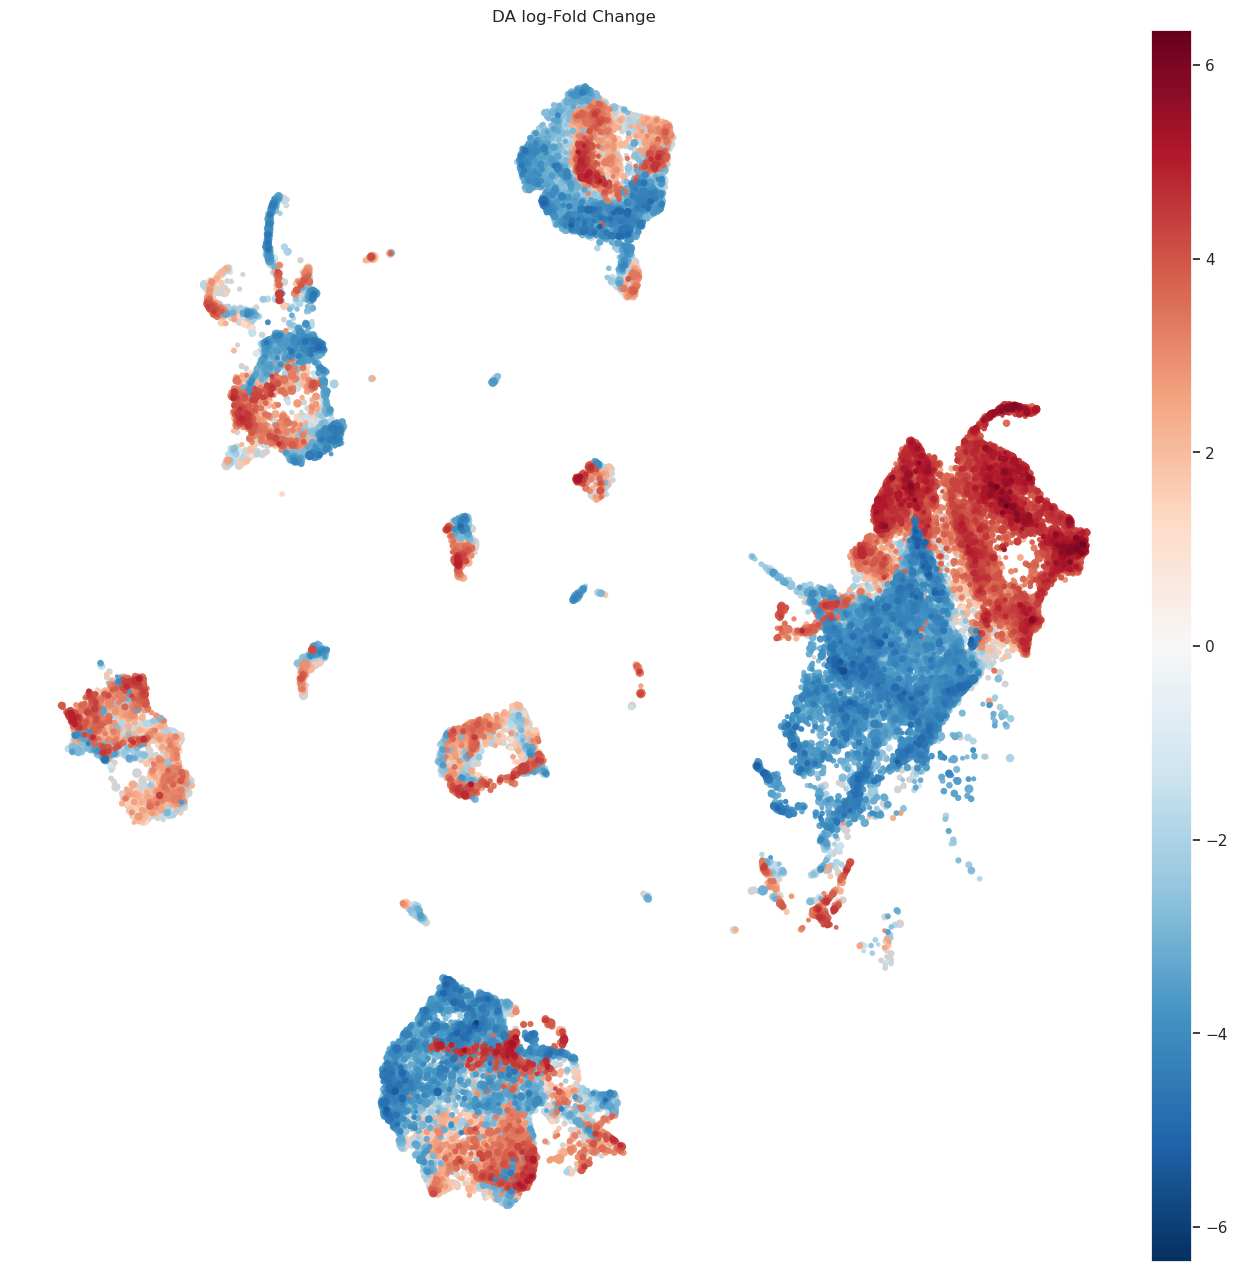

In [12]:

plt.rcParams["figure.figsize"] = [16,16]
milopy.plot.plot_nhood_graph(adata, 
                        alpha=0.1, ## SpatialFDR level (1%) 
                        min_size=2 ## Size of smallest dot
                       )

<Axes: title={'center': 'lvl5_annotation'}, xlabel='UMAP1', ylabel='UMAP2'>

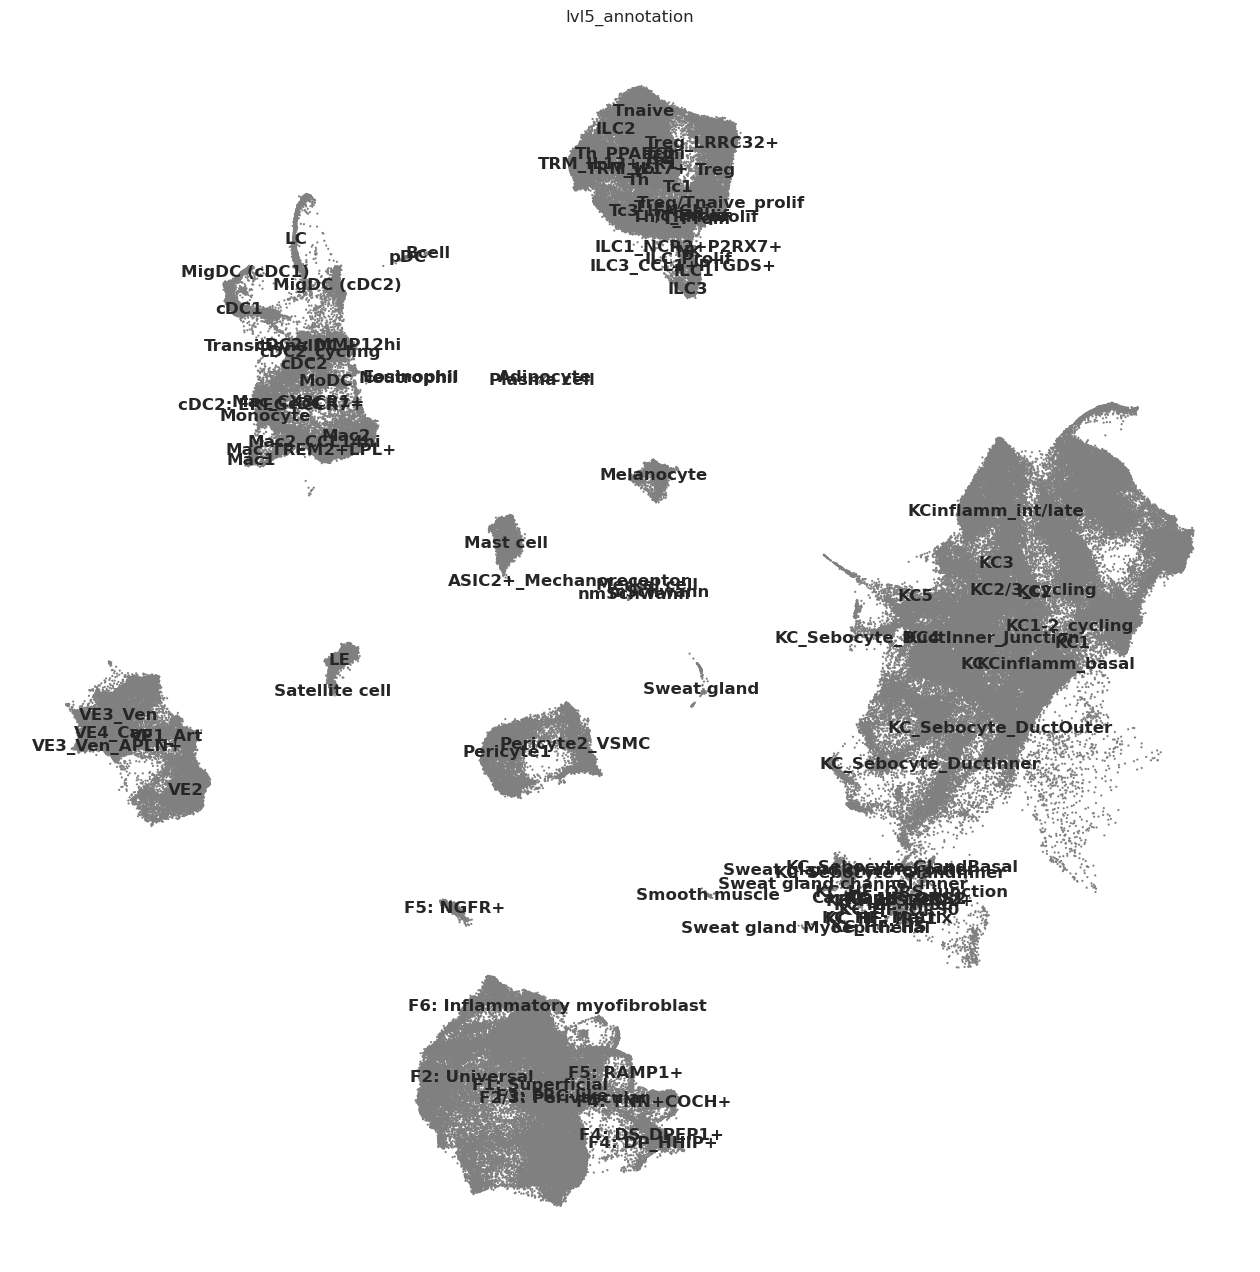

In [13]:
sc.pl.umap(adata, color=ANNOTATION_COL, size=10, cmap='Spectral_r', frameon=False,  legend_loc="on data",
          show=False)


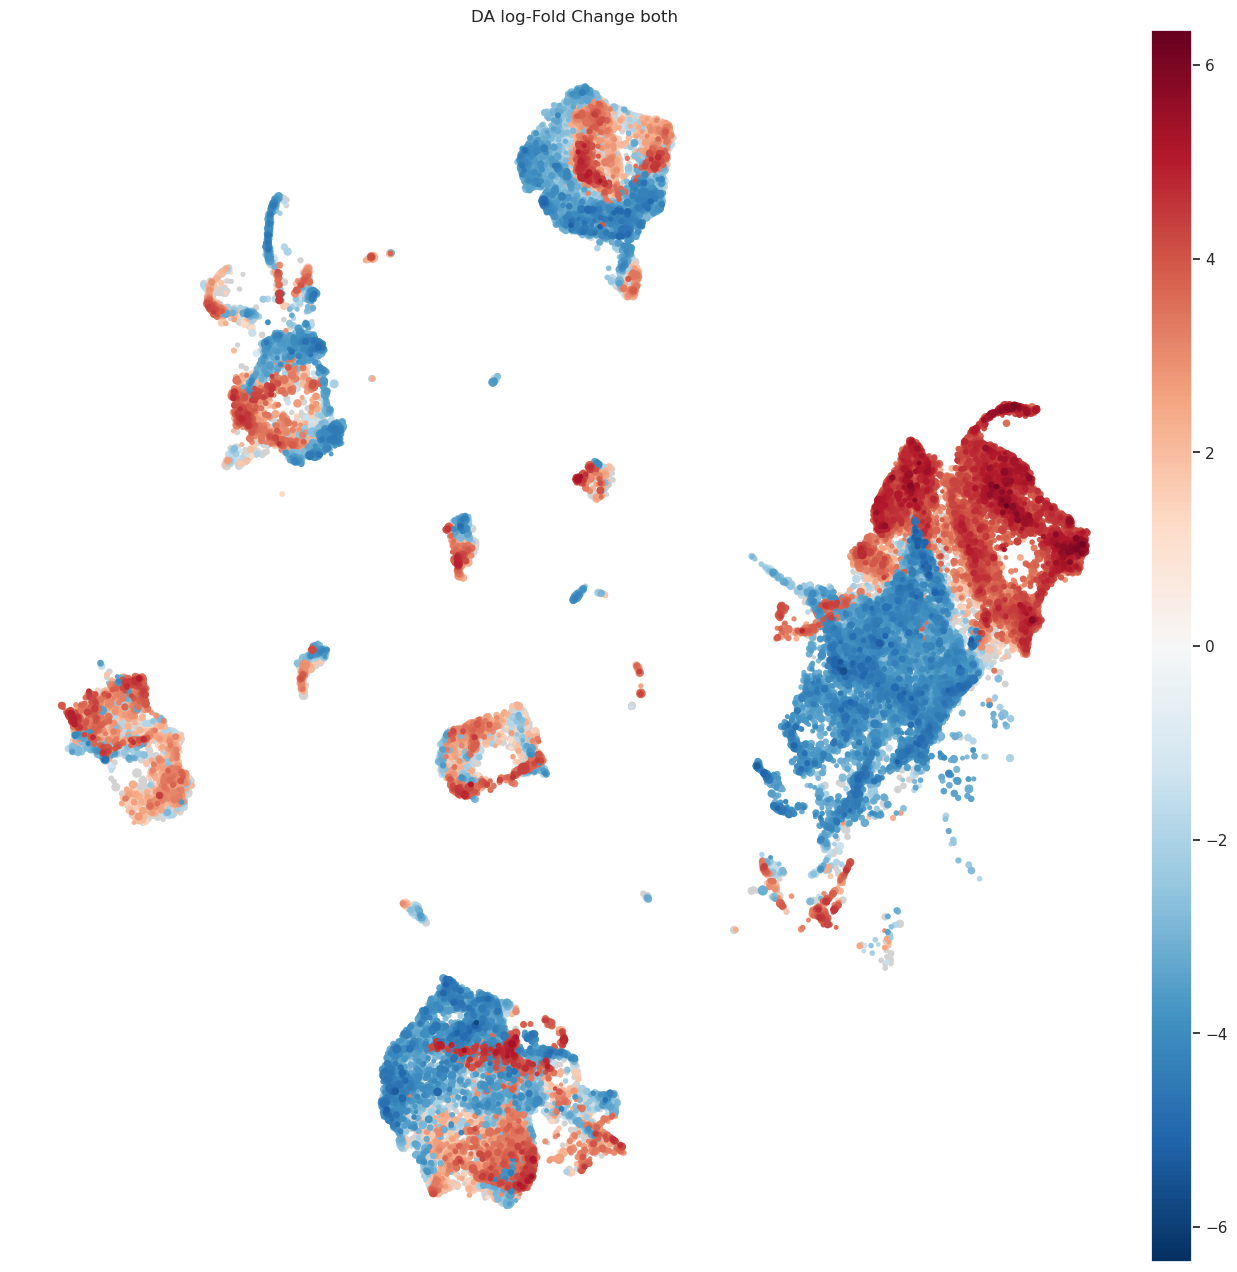

In [15]:

plt.rcParams["figure.figsize"] = [16,16]
milopy.plot.plot_nhood_graph(adata, 
                        alpha=0.1, ## SpatialFDR levfel (1%) 
                        min_size=2 ,## Size of smallest dot
                             #vmax=6,
                             # vmin=6
                             title=f'DA log-Fold Change {DISEASE}',
                                                                                  save="milo_PSO_vs_AD.pdf"

                            )
 

In [16]:

def plot_DA_beeswarm(
    adata,
    anno_col="nhood_annotation",
    alpha=0.1,
    subset_nhoods=None
):
    '''
    Plot beeswarm plot of logFC against nhood labels

    Params:
    -------
    - adata: AnnData object
    - anno_col: column in adata.uns['nhood_adata'].obs to use as annotation
    - alpha: significance threshold
    - subset_nhoods: list of nhoods to plot (default: None, plot all nhoods)
    '''
    try:

        nhood_adata = adata.uns["nhood_adata"].copy()
        if subset_nhoods is not None:
            nhood_adata=nhood_adata[nhood_adata.obs["nhood_annotation"].isin(["MigDC", "MoDC"])]
            #nhood_adata = nhood_adata[nhood_adata.obs]
            #adata.uns["nhood_adata"] = adata.uns["nhood_adata"][adata.uns["nhood_adata"].obs["nhood_annotation"].isin(subset_nhoods)]
        
    except KeyError:
        raise KeyError(
            'Cannot find "nhood_adata" slot in adata.uns -- please run milopy.make_nhoods_adata(adata)'
        )

   # if subset_nhoods is not None:
        #nhood_adata = nhood_adata[subset_nhoods]
      #  nhood_adata = nhood_adata[nhood_adata.obs["nhood_annotation"].isin(subset_nhoods)]

    try:
        nhood_adata.obs[anno_col]
    except KeyError:
        raise KeyError(
            'Cannot find {a} in adata.uns["nhood_adata"].obs -- \
                please run milopy.utils.annotate_nhoods(adata, anno_col) first'.format(a=anno_col)
        )

    try:
        nhood_adata.obs["logFC"]
    except KeyError:
        raise KeyError(
            'Cannot find `logFC` in adata.uns["nhood_adata"].obs -- \
                please run milopy.core.DA_nhoods(adata) first'
        )

    sorted_annos = nhood_adata.obs[[anno_col, "logFC"]].\
        groupby(anno_col).\
        median().\
        sort_values("logFC", ascending=True).index

    anno_df = nhood_adata.obs[[anno_col, "logFC", "SpatialFDR"]].copy()
    anno_df['is_signif'] = anno_df['SpatialFDR'] < alpha
    anno_df = anno_df[anno_df[anno_col] != "nan"]

    try:
        anno_palette = _get_palette_adata(
            adata, nhood_adata.uns['annotation_obs'])
        sns.violinplot(data=anno_df, y=anno_col, x="logFC", order=sorted_annos,
                       inner=None, orient="h",
                       palette=anno_palette,
                       linewidth=0,
                       scale="width")
    except:
        sns.violinplot(data=anno_df, y=anno_col, x="logFC", order=sorted_annos,
                       inner=None, orient="h",
                       linewidth=0,
                       scale="width")

    sns.stripplot(data=anno_df, y=anno_col, x="logFC", order=sorted_annos, size=2,
                  hue='is_signif', palette=['grey', 'black'],
                  orient="h", alpha=0.5)
    plt.legend(loc='upper left', title=f'< {int(alpha*100)}% SpatialFDR',
               bbox_to_anchor=(1, 1), frameon=False)
    plt.axvline(x=0, ymin=0, ymax=1, color="black", linestyle="--")
    plt.yticks(fontsize=8)  # Set y-tick label fontsize
    plt.show()


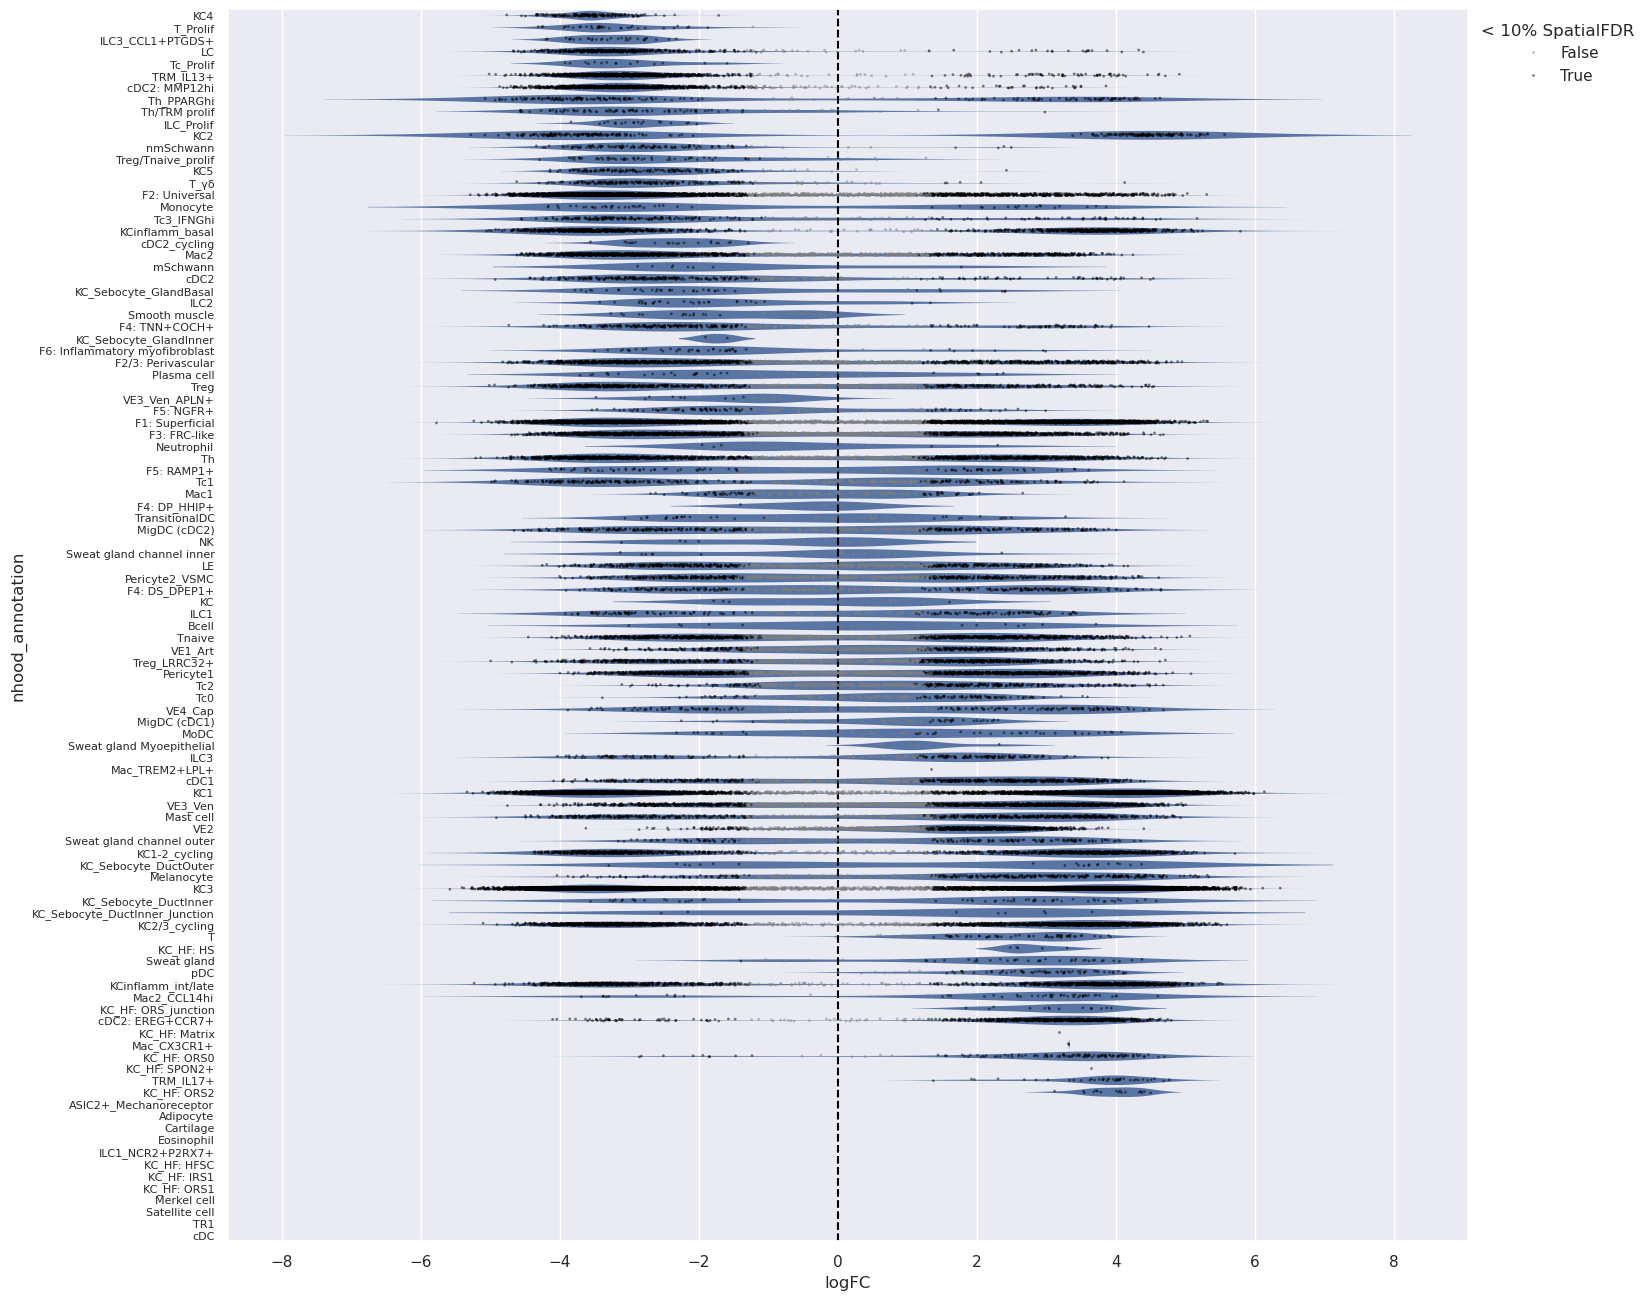

In [17]:
plot_DA_beeswarm(adata)

In [18]:
adata.obs["Site_status_binary"]=adata.obs["Site_status_simple"]

In [19]:

obs_names_to_atlas_status_reynolds_dict = dict(zip(adata.obs_names, adata.obs["Site_status_binary"]))
adata.uns["nhood_adata"].obs["anno_group"] = adata.uns["nhood_adata"].obs["nhood_annotation"].map(rename)

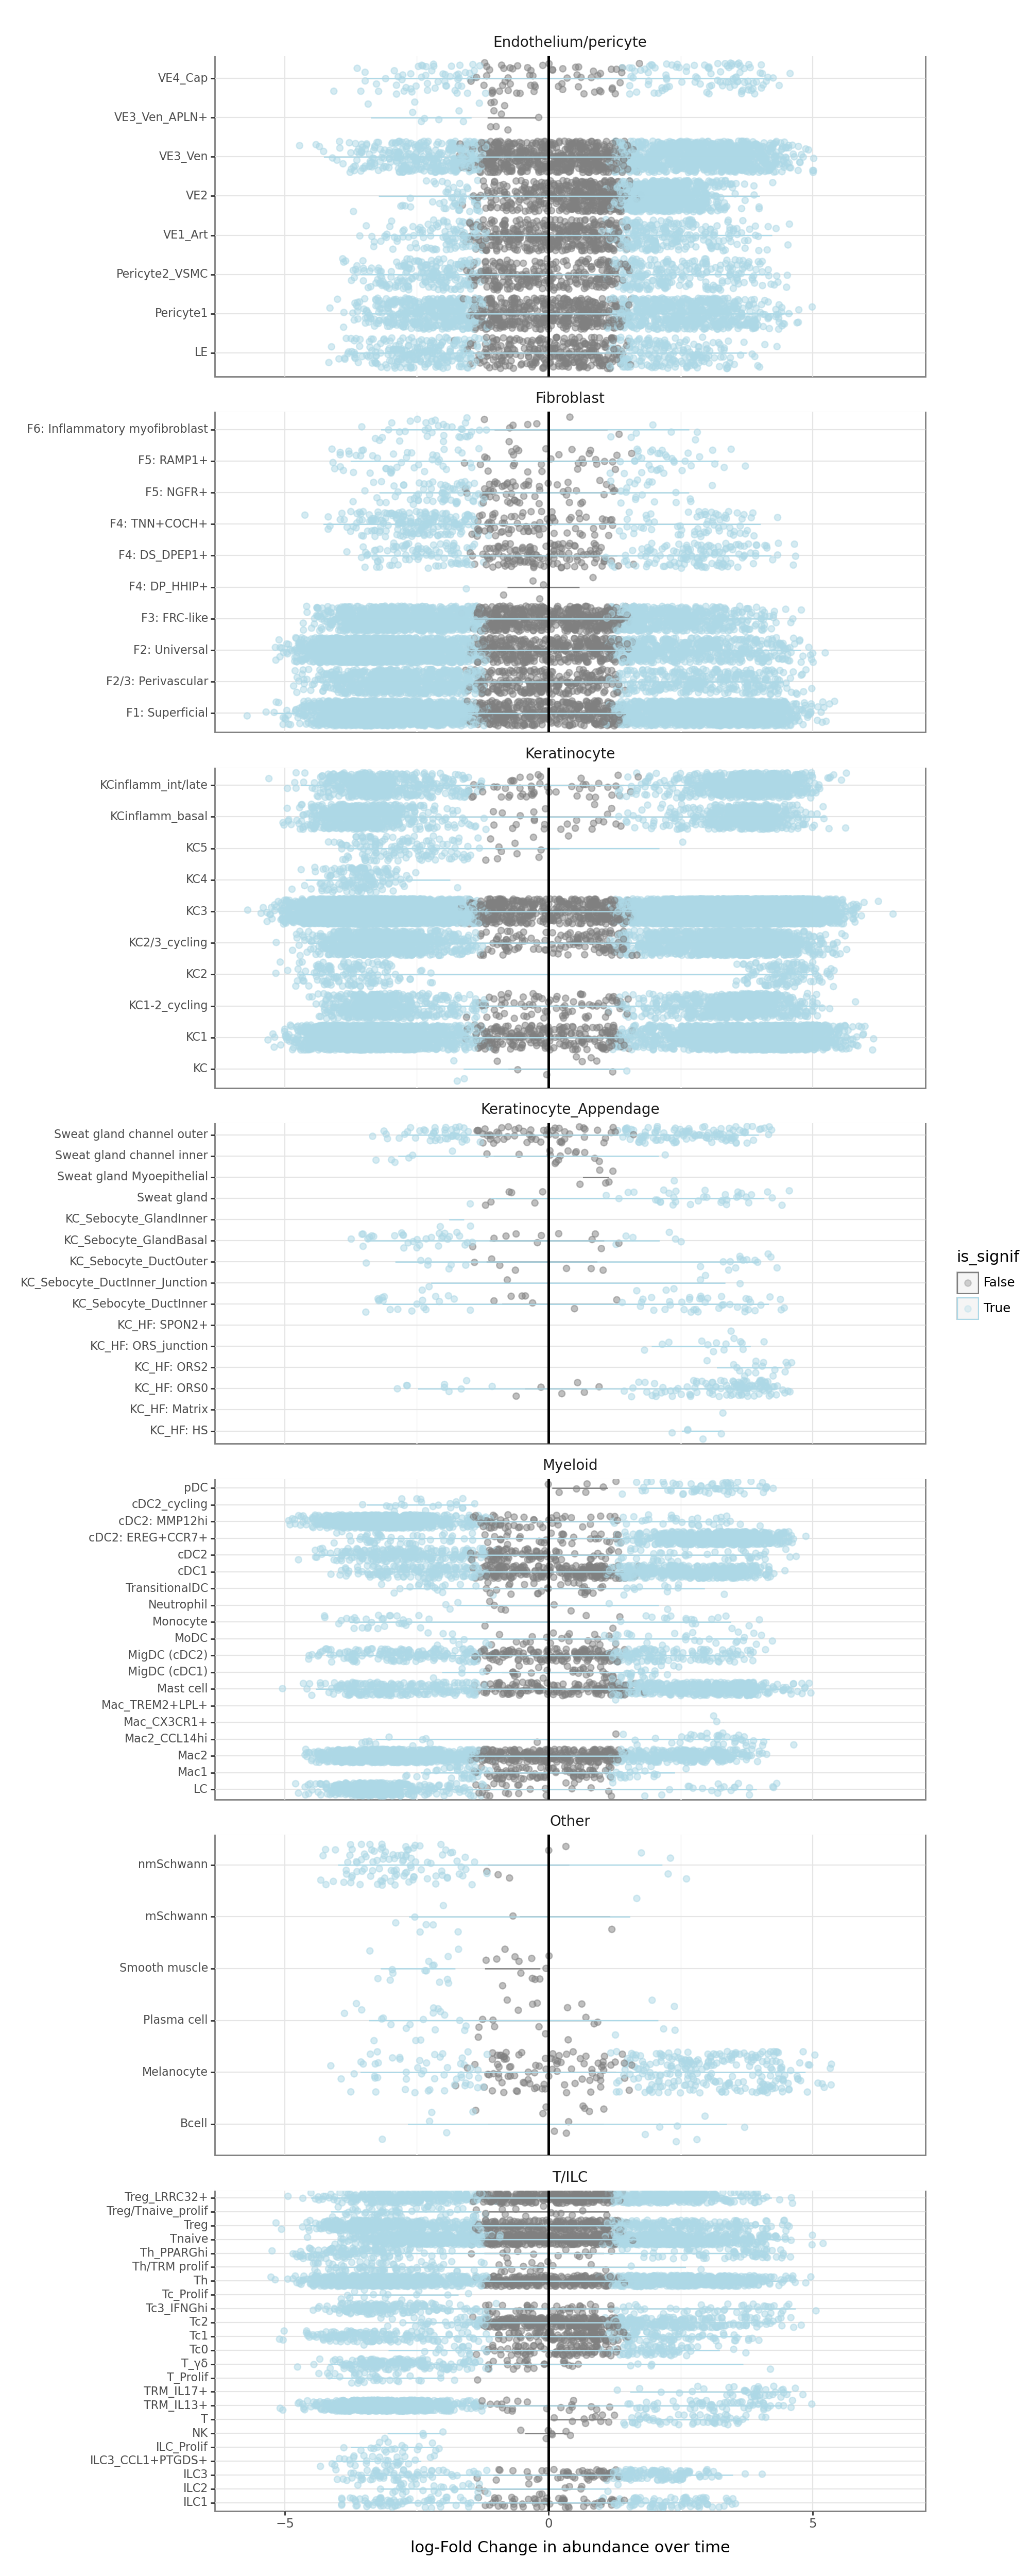

In [20]:

def plot_DA_beeswarm2(
    adata,
    anno_col="nhood_annotation",
    alpha=0.1,
    subset_nhoods=None,
    facet_col="anno_group",  # New parameter for faceting
    plot_height=25  # Parameter to control plot height
):
    '''
    Plot beeswarm plot of logFC against nhood labels

    Params:
    -------
    - adata: AnnData object
    - anno_col: column in adata.uns['nhood_adata'].obs to use as annotation
    - alpha: significance threshold
    - subset_nhoods: list of nhoods to plot (default: None, plot all nhoods)
    - facet_col: column in adata.uns['nhood_adata'].obs to use for faceting (default: "anno_group")
    - plot_height: height of the plot in inches (default: 25)
    '''
    try:
        nhood_adata = adata.uns["nhood_adata"].copy()
    except KeyError:
        raise KeyError(
            'Cannot find "nhood_adata" slot in adata.uns -- please run milopy.make_nhoods_adata(adata)'
        )

    if subset_nhoods is not None:
        nhood_adata = nhood_adata[subset_nhoods]

    if anno_col not in nhood_adata.obs:
        raise KeyError(
            f'Cannot find {anno_col} in adata.uns["nhood_adata"].obs -- \
                please run milopy.utils.annotate_nhoods(adata, anno_col) first'
        )

    if "logFC" not in nhood_adata.obs:
        raise KeyError(
            'Cannot find `logFC` in adata.uns["nhood_adata"].obs -- \
                please run milopy.core.DA_nhoods(adata) first'
        )

    if facet_col not in nhood_adata.obs:
        raise KeyError(
            f'Cannot find {facet_col} in adata.uns["nhood_adata"].obs -- \
                please make sure the column exists.'
        )

    sorted_annos = nhood_adata.obs[[anno_col, "logFC"]].\
        groupby(anno_col).\
        median().\
        sort_values("logFC", ascending=True).index

    anno_df = nhood_adata.obs[[anno_col, "logFC", "SpatialFDR", facet_col]].copy()
    anno_df['is_signif'] = anno_df['SpatialFDR'] < alpha
    anno_df = anno_df[anno_df[anno_col] != "nan"]

    anno_df[anno_col] = pd.Categorical(anno_df[anno_col], categories=sorted_annos, ordered=True)

    # Create the plot
    p = (ggplot(anno_df, aes(x='logFC', y=anno_col))
         + geom_jitter(aes(color='is_signif'), size=2, alpha=0.5, width=0.2)
         + geom_violin(aes(color='is_signif'), scale='width', width=0.8, alpha=0.3)
         + geom_vline(xintercept=0, color='black', linetype='solid', size=1)
         + facet_wrap(f'~ {facet_col}', scales='free_y', ncol=1)
         + scale_color_manual(values=['grey', 'lightblue'])
         + scale_x_continuous(breaks=[-5, 0, 5])
         + labs(x="log-Fold Change in abundance over time", y="")
         + theme_bw()
         + theme(axis_text_y=element_text(size=8, angle=0),
                 strip_text=element_text(size=10),
                 figure_size=(10, plot_height),
                 strip_background=element_text(color="white"),
                 plot_title=element_text(size=0))
        )

    print(p)

plot_DA_beeswarm2(adata, plot_height=25)


In [21]:
import rpy2.rinterface_lib.callbacks
import logging
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)


plot_df = adata.uns['nhood_adata'].obs.copy()
plot_df['group'] = plot_df['nhood_annotation'].map(rename)
plot_df["organ"] = plot_df["index_cell"].map(obs_names_to_atlas_status_reynolds_dict)
plot_df.head(2)
plot_df.rename(columns={"group": "anno_group"}, inplace=True)
plot_df.rename(columns={"Nhood_size": "Nhood"}, inplace=True)
plot_df.rename(columns={"nhood_annotation": "nhood_anno"}, inplace=True)

#plot_df['organ'] = plot_df['anno_group']
plot_df["mean_logFC"] = plot_df["logFC"]
plot_df = plot_df.drop(columns='FDR')
plot_df = plot_df.drop(columns='F')
plot_df = plot_df.drop(columns='kth_distance')

#df = df.drop(columns='kth_distance')
plot_df = plot_df.drop(columns='logCPM')
plot_df = plot_df.drop(columns='nhood_annotation_frac')


In [22]:
%%R -w 1200 -h 600 -i plot_df -o plot_df
    library(ggbeeswarm)
    library(dplyr)

    plot_df  %>%
        filter(!is.na(logFC)) %>%
        filter(nhood_anno!="nan") %>%
        filter(nhood_anno!="Mixed") %>%

        ## Reorder by fold-change 
        group_by(organ, nhood_anno, Nhood) %>%
        mutate(mean_logFC = mean(logFC)) %>%
        ungroup() %>%
        group_by(organ, nhood_anno) %>%
        arrange(- mean_logFC) %>%
        ungroup()  %>%
        mutate(Nhood=factor(Nhood, levels=unique(Nhood))) %>%
        group_by(nhood_anno) %>%
        filter(length(unique(Nhood)) > 20) %>%
        ungroup()
    head(plot_df)



                   index_cell         nhood_anno    logFC       PValue
0 GTACGTAGTACCAGTT_GSM5277189 KCinflamm_int/late 3.856520 9.502879e-08
1 ACCGTAAAGGCAGTCA_GSM5277189 KCinflamm_int/late 3.960729 8.338277e-08
2 CTAGAGTTCATCGATG_GSM5277189                KC3 5.009416 1.584696e-07
3 CCACGGAAGTCCGTAT_GSM5277189                KC3 3.793637 1.094574e-07
4 CCGTTCATCTGCTTGC_GSM5277189                KC3 4.441843 1.066210e-07
5 GAGTCCGAGCTAGCCC_GSM5277189 KCinflamm_int/late 3.468536 8.668428e-06
    SpatialFDR Nhood   anno_group    organ mean_logFC
0 1.068564e-06    29 Keratinocyte Lesional   3.856520
1 1.068564e-06    30 Keratinocyte Lesional   3.960729
2 1.068564e-06    59 Keratinocyte Lesional   5.009416
3 1.068564e-06    26 Keratinocyte Lesional   3.793637
4 1.068564e-06    40 Keratinocyte Lesional   4.441843
5 2.027586e-05    29 Keratinocyte Lesional   3.468536


Loading required package: ggplot2

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

In addition: Warning messages:
1: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library ‘/usr/lib/R/site-library’ contains no packages
2: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library ‘/usr/lib/R/site-library’ contains no packages
3: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library ‘/usr/lib/R/site-library’ contains no packages
4: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library ‘/usr/lib/R/site-library’ contains no packages
5: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library ‘/usr/lib/R/site-library’ contains no packages


In [23]:
%%R -w 1200 -h 600 -o pl_df
library(ggbeeswarm)
library(dplyr)

organ_palette <- c("Eczema_lesional" = "#1A43BF", "Eczema_lesional" =  "#1A43BF")
anno_group_order <- c('Keratinocyte', 'T/ILC', 'Myeloid', 'Other',
   'Fibroblast', 'Endothelium/pericyte')

pl_df <- plot_df %>%
    mutate(mean_logFC=ifelse(logFC > 0, logFC, 0)) %>%
    ## Reorder annotation names by median FC
    group_by(nhood_anno) %>%
    #mutate(mean_logFC = median(logFC)) %>%
    ungroup() %>%
    arrange(mean_logFC) %>%
    mutate(nhood_anno=factor(nhood_anno, levels=unique(nhood_anno))) %>%
    ## Calculate median per organ, to plot
    group_by(organ, nhood_anno) %>%
    #mutate(mean_logFC = median(logFC)) %>%
    ungroup() %>%
    mutate(anno_group=factor(anno_group, levels=anno_group_order)) %>%
    filter(!is.na(anno_group)) %>%
    filter(anno_group %in% anno_group_order)
    head(pl_df)



# A tibble: 6 × 9
  index_cell          nhood_anno  logFC PValue SpatialFDR Nhood anno_group organ
  <chr>               <fct>       <dbl>  <dbl>      <dbl> <dbl> <fct>      <chr>
1 TTCGGTCCAGTGAGTG_G… F1: Super… -0.366  0.662      0.683    50 Fibroblast Lesi…
2 GTGCAGCCAGATAATG_G… Pericyte2… -1.13   0.146      0.164    40 Endotheli… Lesi…
3 GTCATTTGTCAGAGGT_G… KCinflamm… -0.199  0.808      0.822    37 Keratinoc… Lesi…
4 GGAAAGCTCTTCATGT_G… cDC2: MMP… -0.155  0.830      0.843    27 Myeloid    Lesi…
5 GGGACCTCATCTACGA_G… Smooth mu… -0.627  0.380      0.405    21 Other      Lesi…
6 CCATTCGCAGATGAGC_G… KC3        -0.548  0.510      0.535    50 Keratinoc… Lesi…
# ℹ 1 more variable: mean_logFC <dbl>


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
✔ readr     2.1.5     


System has not been booted with systemd as init system (PID 1). Can't operate.
Failed to create bus connection: Host is down


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In addition: Warning message:
In system("timedatectl", intern = TRUE) :
  running command 'timedatectl' had status 1


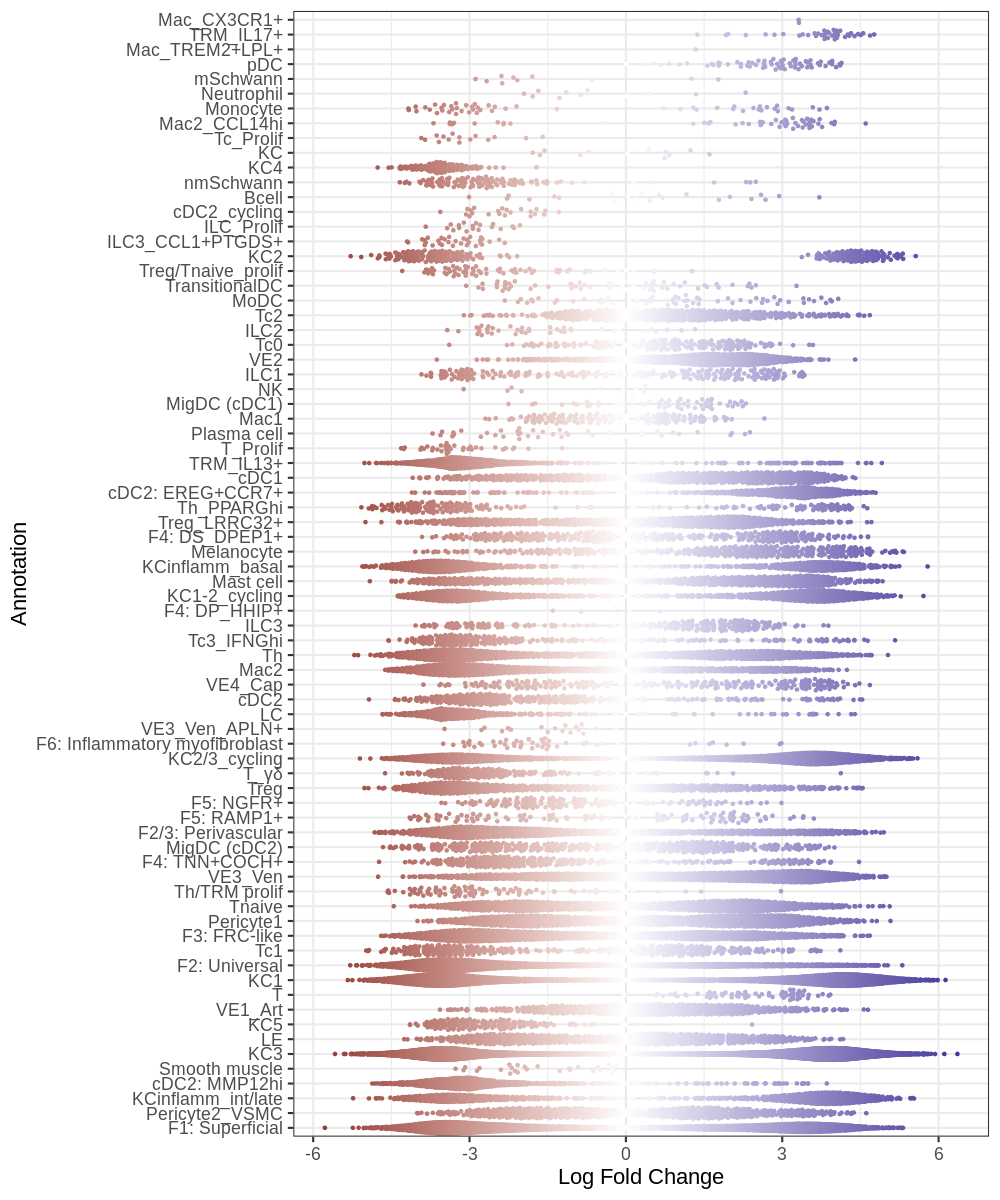

In [24]:
%%R -w 1000 -h 1200
library(tidyverse)
library(ggbeeswarm)

pl_df %>% 
 mutate(is_signif = ifelse(SpatialFDR < 1, 1, 0)) %>%
    mutate(logFC_color = ifelse(is_signif==1, logFC, NA)) %>%
    ggplot(aes(nhood_anno, logFC, color=logFC_color)) +
    scale_color_gradient2() +
    guides(color="none") +
    xlab("Annotation") + ylab("Log Fold Change") +
    geom_quasirandom(alpha=1) +
    coord_flip() +
    theme_bw(base_size=22) +
    theme(strip.text.y =  element_text(angle=0))
    


In [25]:
OTHER = [ 'KC1',
                'KC2',
 'KC1-2_cycling',
 'KC2/3_cycling',
 'KC3',
 'KC4',
 'KC5',
 'KCinflamm_basal',
 'KCinflamm_int/late', 'KC',
                'KC_HF: HFSC',#'KC_HF: HFSC',
                'KC_HF: ORS-Bulb/infundibulum','KC_HF: SPON2+',
           
 'KC_HF: ORS0',
                'KC_HF: ORS1', 'KC_HF: ORS2',
 'KC_HF: ORS_cycling', 

 'KC_HF: IRS', 'KC_HF: IRS0', 'KC_HF: IRS1', 'KC_HF: IRS2',
 'KC_HF: IRS_TCHH+',
 'KC_HF: IRS_cycling',
                
                'KC_HF: Matrix',





















                
 'KC_HF: HS','KC_HF: HS1',
              'KC_HF: ORS_junction',

'KC_Sebocyte_DuctOuter', 'KC_Sebocyte_DuctInner',
                
 'KC_SebocyteDuct_Outer/HF_Junction','KC_Sebocyte_DuctInner_Junction',
 'KC_SebocyteGland_Outer','KC_Sebocyte_GlandBasal',
                'KC_Sebocyte_GlandInner',
 'Sweat gland',
 'Sweat gland Myoepithelial',
 'Sweat gland channel inner',
 'Sweat gland channel outer',
 'TRM_IL13+',

                'TRM_IL17+',

 'TRM_ZNF683+',   'T_γδ',#T_γδ
                 'Treg',
 'Treg_LRRC32+',
 'TR1',
                 'Tnaive',
 'Th',
 'Tc_IL9R+GPR15hi',
                'Tc_GPR15hi',
                'Tc0',
 'Tc1',
 'Tc2',
 'Tc3_IFNGhi',

 'T_Prolif',
 'Th_CXCR6+',
 'Th_PPARGhi',
'T',
                'Th/TRM prolif',
                'Treg/Tnaive_prolif','Tc_Prolif',
                
 'NK',
 'ILC1',
 'ILC1_NCR2+P2RX7+',
 'ILC3',
 'ILC3_CCL1+PTGDS+', 
 'ILC_prolif','ILC_Prolif',
 'ILC2',
 'Bcell',
 'Plasma cell',
 'LC',
 'MigDC (cDC1)',
 'MigDC (cDC2)','cDC',
 'cDC1',
 'cDC2: MMP12hi',
 'cDC2',
 'cDC2: EREG+CCR7+',
 'cDC2_cycling',
 'TransitionalDC',
 'pDC',
 'pDC_IGKJ5+',
 'pDC_CXCL2+CXCL3+',
 'pDC_LAMP5+',
 'MoDC',
 'Monocyte',
 'Mac1',
 'Mac2',
 'Mac2_CCL14hi',
 'Mac_CX3CR1+',
 'Mac_TREM2+LPL+',
                 'Eosinophil',
 'Neutrophil',
                 'Mast cell',
 'F1: Superficial',
 'F2: Universal',
 'F2/3: Perivascular',
 'F3: FRC-like',
 'F4: DS_DPEP1+',
 'F4: TNN+COCH+',
 'F4: DP_HHIP+',
 'F5: RAMP1+',
 'F5: NGFR+',
 'F6: Inflammatory myofibroblast',
 'VE1_Art',
 'VE2',
 'VE3_Ven',
'VE3_Ven_APLN+',
 'VE4_Cap',
 'VE4_Cap_APLN+',
 'LE',
 'Pericyte1',
 'Pericyte2_VSMC',
 'Smooth muscle',
 'Satellite cell',
 'mSchwann',
 'nmSchwann',
 'Adipocyte',
 'Cartilage',
 'Melanocyte',
 'Merkel cell',
 'Mechanoreceptor ASIC2+','ASIC2+_Mechanoreceptor'
 ]

In [26]:
included = list(adata.obs.lvl5_annotation.unique())
for x in included:
    if x not in OTHER:
        print(x)

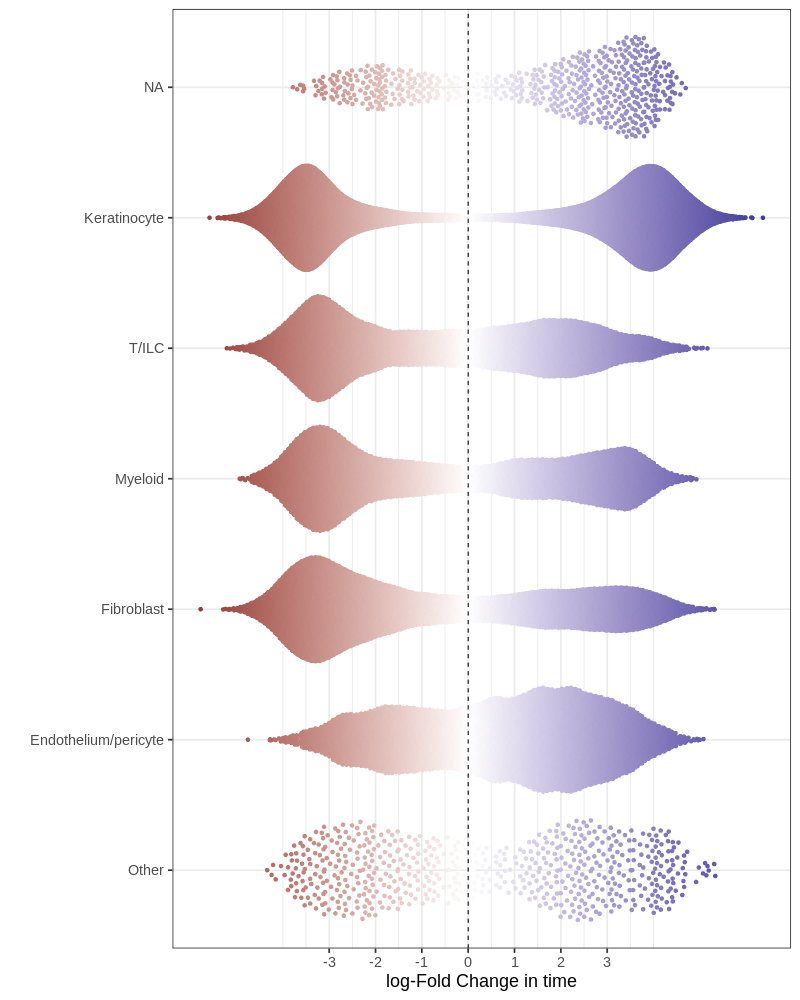

In [27]:
%%R -w 800 -h 1000

plot_df_copy <- plot_df

# Define the correct order for 'anno_group' and 'nhood_anno'
anno_group_order <- c('Keratinocyte', 'T/ILC', 'Myeloid', 'Fibroblast', 'Endothelium/pericyte', 'Other')


anno_order <- c( 'KC1',
                'KC2',
 'KC1-2_cycling',
 'KC2/3_cycling',
 'KC3',
 'KC4',
 'KC5',
 'KCinflamm_basal',
 'KCinflamm_int/late', 'KC',
                'KC_HF: HFSC',#'KC_HF: HFSC',
                'KC_HF: ORS-Bulb/infundibulum','KC_HF: SPON2+',
                'KC_HF: ORS_junction',
 'KC_HF: ORS0',
                'KC_HF: ORS1', 'KC_HF: ORS2',
 'KC_HF: ORS_cycling', 

 'KC_HF: IRS', 'KC_HF: IRS0', 'KC_HF: IRS1', 'KC_HF: IRS2',
 'KC_HF: IRS_TCHH+',
 'KC_HF: IRS_cycling',
                
                'KC_HF: Matrix',





















                
 'KC_HF: HS','KC_HF: HS1',

'KC_Sebocyte_DuctOuter', 'KC_Sebocyte_DuctInner',
                
 'KC_SebocyteDuct_Outer/HF_Junction','KC_Sebocyte_DuctInner_Junction',
 'KC_SebocyteGland_Outer','KC_Sebocyte_GlandBasal',
                'KC_Sebocyte_GlandInner',
 'Sweat gland',
 'Sweat gland Myoepithelial',
 'Sweat gland channel inner',
 'Sweat gland channel outer',
 'TRM_IL13+',

                'TRM_IL17+',

 'TRM_ZNF683+',   'T_γδ',#T_γδ
                 'Treg',
 'Treg_LRRC32+',
 'TR1',
                 'Tnaive',
 'Th',
 'Tc_IL9R+GPR15hi',
                'Tc_GPR15hi',
                'Tc0',
 'Tc1',
 'Tc2',
 'Tc3_IFNGhi',


 'Th_CXCR6+',
 'Th_PPARGhi',
'T', 'T_Prolif',
                'Th/TRM prolif',
                'Treg/Tnaive_prolif','Tc_Prolif',
                
 'NK',
 'ILC1',
 'ILC1_NCR2+P2RX7+',
 'ILC3',
 'ILC3_CCL1+PTGDS+', 
 'ILC_prolif','ILC_Prolif',
 'ILC2',
 'Bcell',
 'Plasma cell',
 'LC',
                 'cDC2: EREG+CCR7+',
                 'pDC',
 'MigDC (cDC1)',
 'MigDC (cDC2)','cDC',
 'cDC1',
 'cDC2: MMP12hi',
 'cDC2',

 'cDC2_cycling',
 'TransitionalDC',

 'pDC_IGKJ5+',
 'pDC_CXCL2+CXCL3+',
 'pDC_LAMP5+',
 'MoDC',
 'Monocyte',
 'Mac1',
 'Mac2',
 'Mac2_CCL14hi',
 'Mac_CX3CR1+',
 'Mac_TREM2+LPL+',
                 'Eosinophil',
 'Neutrophil',
                 'Mast cell',
 'F1: Superficial',
 'F2: Universal',
 'F2/3: Perivascular',
 'F3: FRC-like',
 'F4: DS_DPEP1+',
 'F4: TNN+COCH+',
 'F4: DP_HHIP+',
 'F5: RAMP1+',
 'F5: NGFR+',
 'F6: Inflammatory myofibroblast',
 'VE1_Art',
 'VE2',
 'VE3_Ven',
'VE3_Ven_APLN+',
 'VE4_Cap',
 'VE4_Cap_APLN+',
 'LE',
 'Pericyte1',
 'Pericyte2_VSMC',
 'Smooth muscle',
 'Satellite cell',
 'mSchwann',
 'nmSchwann',
 'Adipocyte',
 'Cartilage',
 'Melanocyte',
 'Merkel cell',
 'Mechanoreceptor ASIC2+','ASIC2+_Mechanoreceptor'
                          )
 
 
 

# Assign factor levels
plot_df_copy$anno_group = factor(plot_df_copy$anno_group, levels = rev(anno_group_order))
plot_df_copy$nhood_anno = factor(plot_df_copy$nhood_anno, levels = anno_order)

# Plot the data
pl3 <- plot_df_copy %>% 
    mutate(is_signif = ifelse(SpatialFDR < 1, 1, 0)) %>%
    mutate(logFC_color = ifelse(is_signif == 1, logFC, NA)) %>%
    ggplot(aes(anno_group, logFC, color = logFC_color)) +
    scale_color_gradient2() +
    geom_quasirandom(alpha = 1) +
    coord_flip() +
    guides(color = "none", fill = "none") +
    geom_hline(yintercept = 0, linetype = 2) +
    theme_bw(base_size = 18) +
    xlab("") + 
    ylab("log-Fold Change in time") +
    scale_y_continuous(breaks = seq(-3, 3, by = 1)) +
    theme(strip.text.y = element_text(angle = 0))

print(pl3)



In [28]:
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(15,15))


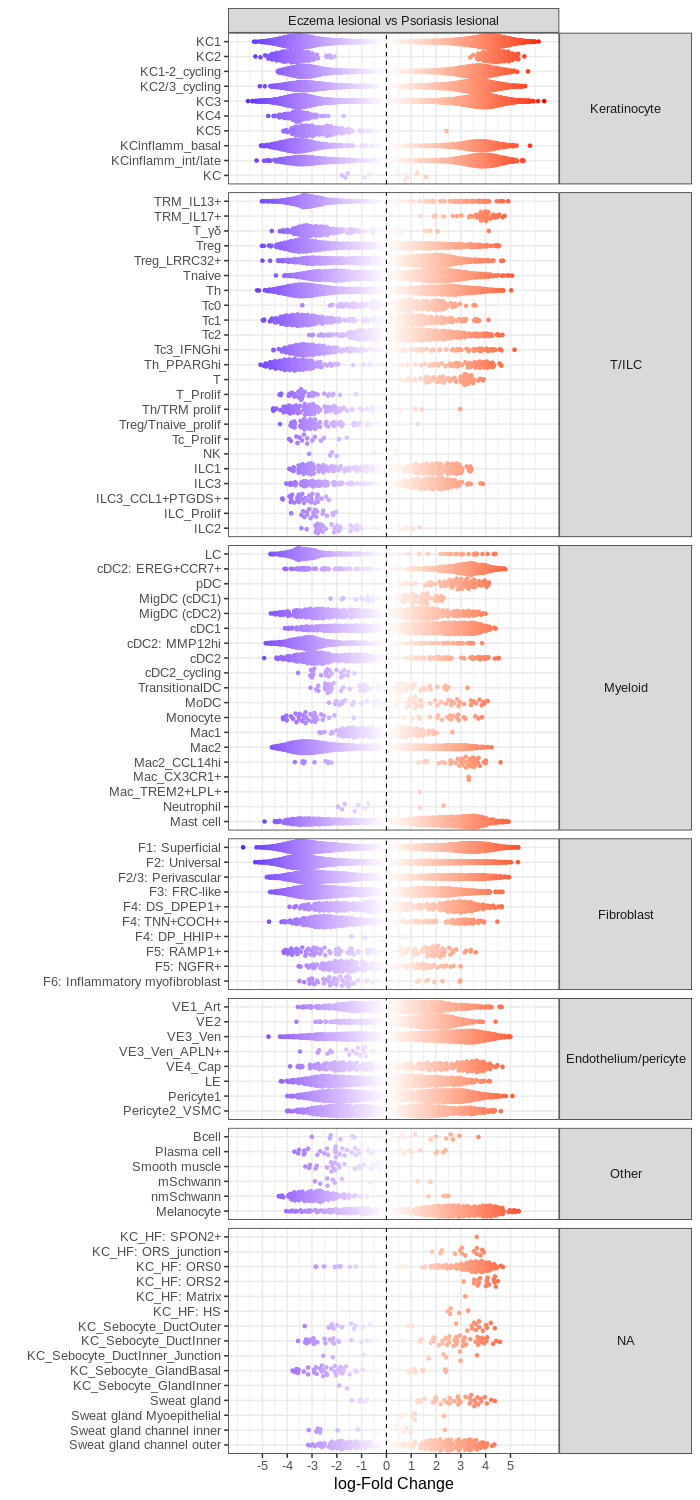

In [29]:
%%R -w 700 -h 1500

plot_df_copy <- plot_df

plot_df_copy$anno_group = factor(plot_df_copy$anno_group, levels = (anno_group_order))
plot_df_copy$nhood_anno = factor(plot_df_copy$nhood_anno, levels = rev(anno_order))
plot_df_copy$organ = 'Eczema lesional vs Psoriasis lesional'

pl4 <- plot_df_copy %>% 
    mutate(is_signif = ifelse(SpatialFDR < 1, 1, 0)) %>%
    mutate(logFC_color = ifelse(is_signif == 1, logFC, NA)) %>%
    ggplot(aes(nhood_anno, logFC, color = logFC_color)) +
    # Set the color gradient to have red for positive and blue for negative values
    scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
    geom_quasirandom(alpha = 1) +
    facet_grid(anno_group ~ organ, scales = "free", space = "free_y") +
    coord_flip() +
    guides(color = "none", fill = "none") +
    geom_hline(yintercept = 0, linetype = 2) +
    theme_bw(base_size = 16) +
    xlab("") + ylab("log-Fold Change") +
    scale_y_continuous(breaks = seq(-5, 5, by = 1)) +
    theme(strip.text.y = element_text(angle = 0))
pl4





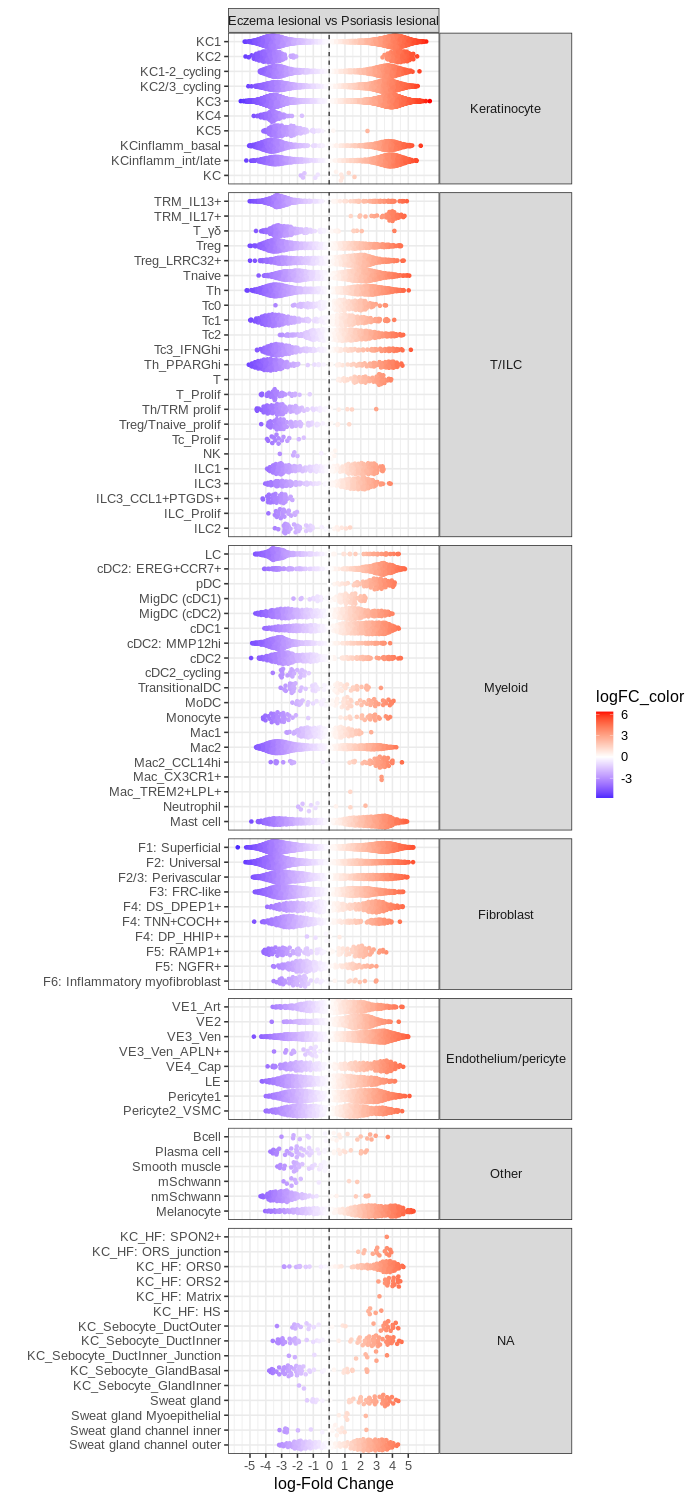

In [30]:
%%R -w 700 -h 1500

plot_df_copy <- plot_df

plot_df_copy$anno_group = factor(plot_df_copy$anno_group, levels = (anno_group_order))
plot_df_copy$nhood_anno = factor(plot_df_copy$nhood_anno, levels = rev(anno_order))
plot_df_copy$organ = 'Eczema lesional vs Psoriasis lesional'

pl4 <- plot_df_copy %>% 
    mutate(is_signif = ifelse(SpatialFDR < 1, 1, 0)) %>%
    mutate(logFC_color = ifelse(is_signif == 1, logFC, NA)) %>%
    ggplot(aes(nhood_anno, logFC, color = logFC_color)) +
    # Set the color gradient to have red for positive and blue for negative values
    scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0, na.value = "gray") +
    geom_quasirandom(alpha = 1) +
    facet_grid(anno_group ~ organ, scales = "free", space = "free_y") +
    coord_flip() +
    guides(fill = "none") +  # Hide fill guide
    geom_hline(yintercept = 0, linetype = 2) +
    theme_bw(base_size = 16) +
    xlab("") + ylab("log-Fold Change") +
    scale_y_continuous(breaks = seq(-5, 5, by = 1)) +
    theme(strip.text.y = element_text(angle = 0))
pl4

In addition: Warning message:
The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


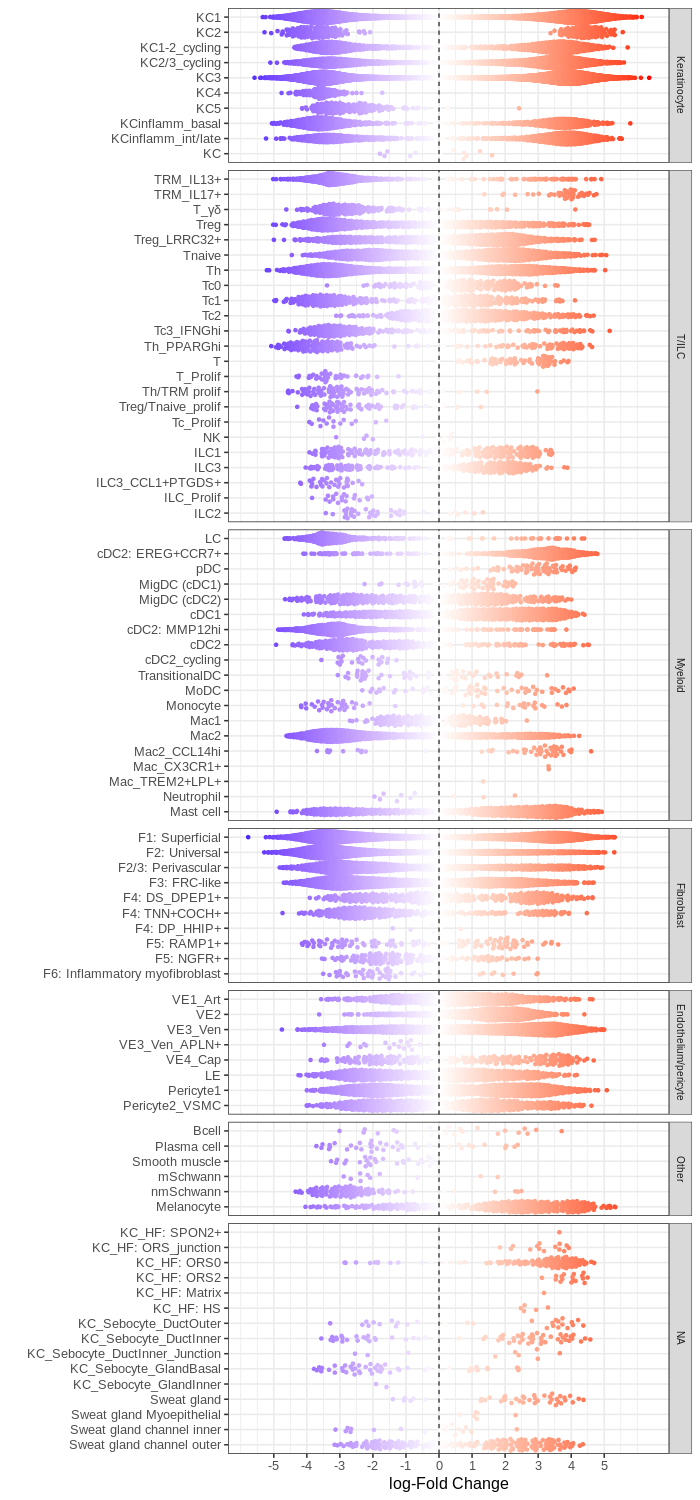

In [31]:
%%R -w 700 -h 1500

pl4 <- plot_df_copy %>% 
    mutate(is_signif = ifelse(SpatialFDR < 1, 1, 0)) %>%
    mutate(logFC_color = ifelse(is_signif == 1, logFC, NA)) %>%
    ggplot(aes(nhood_anno, logFC, color = logFC_color)) +
    # Set the color gradient to have red for positive and blue for negative values
    scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
    geom_quasirandom(alpha = 1) +
    facet_grid(anno_group ~ organ, scales = "free", space = "free_y") +
    coord_flip() +
    guides(color = "none", fill = "none") +
    geom_hline(yintercept = 0, linetype = 2) +
    theme_bw(base_size = 16) +
    xlab("") + ylab("log-Fold Change") +
    scale_y_continuous(breaks = seq(-5, 5, by = 1)) +
    theme(
        strip.text.x = element_blank(),  # Remove the title on top
        strip.text.y = element_text(size = 10),  # Smaller strip text size
        strip.background = element_rect(size = 0.5),  # Reduce strip box size
        panel.spacing = unit(0.5, "lines")  # Adjust space between panels
    )  
pl4

     #  strip.text.y = element_text(angle = 0)  # Keep the left facet labels

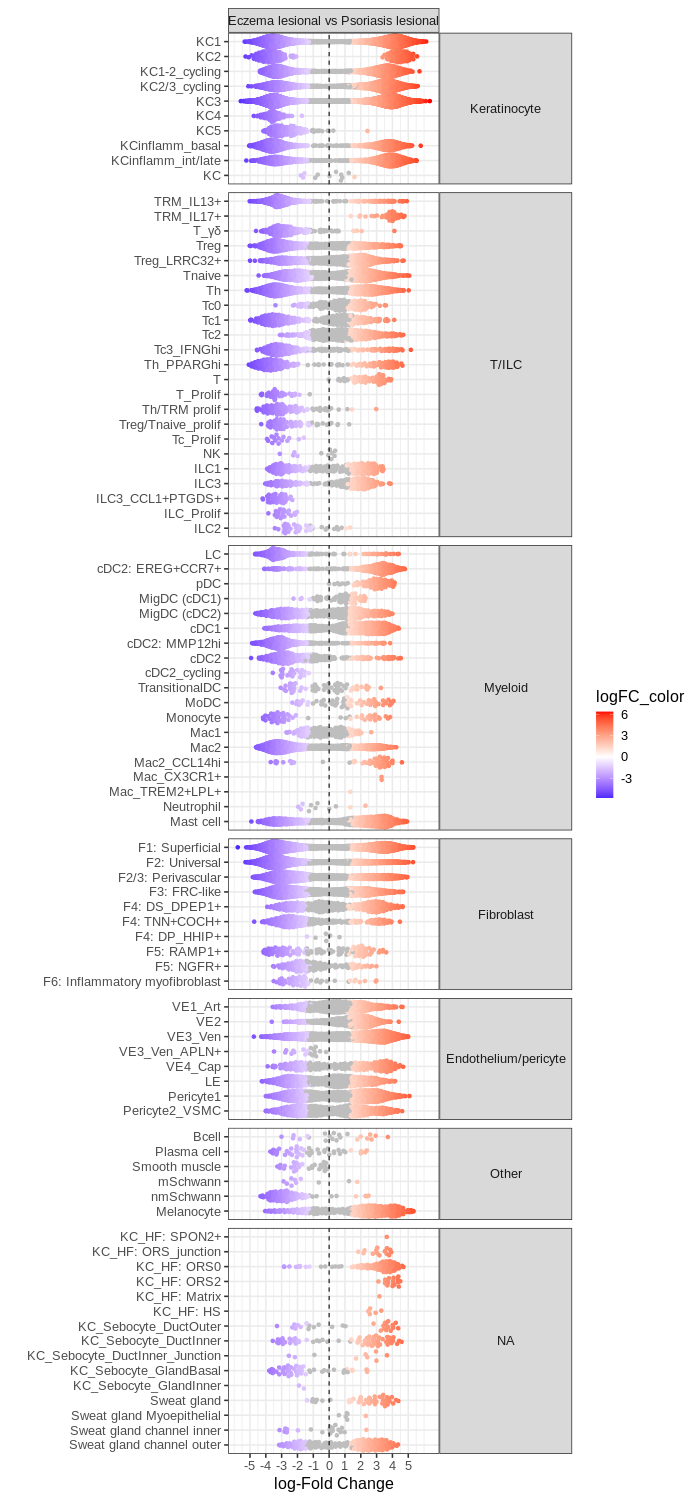

In [32]:
%%R -w 700 -h 1500

plot_df_copy <- plot_df

plot_df_copy$anno_group = factor(plot_df_copy$anno_group, levels = (anno_group_order))
plot_df_copy$nhood_anno = factor(plot_df_copy$nhood_anno, levels = rev(anno_order))
plot_df_copy$organ = 'Eczema lesional vs Psoriasis lesional'

pl4 <- plot_df_copy %>% 
    mutate(is_signif = ifelse(SpatialFDR < 0.1, 1, 0)) %>%
    mutate(logFC_color = ifelse(is_signif == 1, logFC, NA)) %>%
    ggplot(aes(nhood_anno, logFC, color = logFC_color)) +
    # Set the color gradient to have red for positive and blue for negative values
    scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0, na.value = "gray") +
    geom_quasirandom(alpha = 1) +
    facet_grid(anno_group ~ organ, scales = "free", space = "free_y") +
    coord_flip() +
    guides(fill = "none") +  # Hide fill guide
    geom_hline(yintercept = 0, linetype = 2) +
    theme_bw(base_size = 16) +
    xlab("") + ylab("log-Fold Change") +
    scale_y_continuous(breaks = seq(-5, 5, by = 1)) +
    theme(strip.text.y = element_text(angle = 0))
pl4

In [33]:
# %%R -w 700 -h 1500

# plot_df_copy <- plot_df

# plot_df_copy$anno_group = factor(plot_df_copy$anno_group, levels = (anno_group_order))
# plot_df_copy$nhood_anno = factor(plot_df_copy$nhood_anno, levels = rev(anno_order))
# plot_df_copy$organ = 'Eczema lesional vs Psoriasis lesional'

# pl4 <- plot_df_copy %>% 
#     mutate(is_signif = ifelse(SpatialFDR < 0.1, 1, 0)) %>%
#     mutate(logFC_color = ifelse(is_signif == 1, logFC, NA)) %>%
#     ggplot(aes(nhood_anno, logFC, color = logFC_color)) +
#     # Set the color gradient to have red for positive and blue for negative values
#     scale_color_gradient2(low = "red", mid = "white", high = "red", midpoint = 0, na.value = "gray") +
#     geom_quasirandom(alpha = 1) +
#     facet_grid(anno_group ~ organ, scales = "free", space = "free_y") +
#     coord_flip() +
#     guides(fill = "none") +  # Hide fill guide
#     geom_hline(yintercept = 0, linetype = 2) +
#     theme_bw(base_size = 16) +
#     xlab("") + ylab("log-Fold Change") +
#     scale_y_continuous(breaks = seq(-5, 5, by = 1)) +
#     theme(strip.text.y = element_text(angle = 0))
# pl4

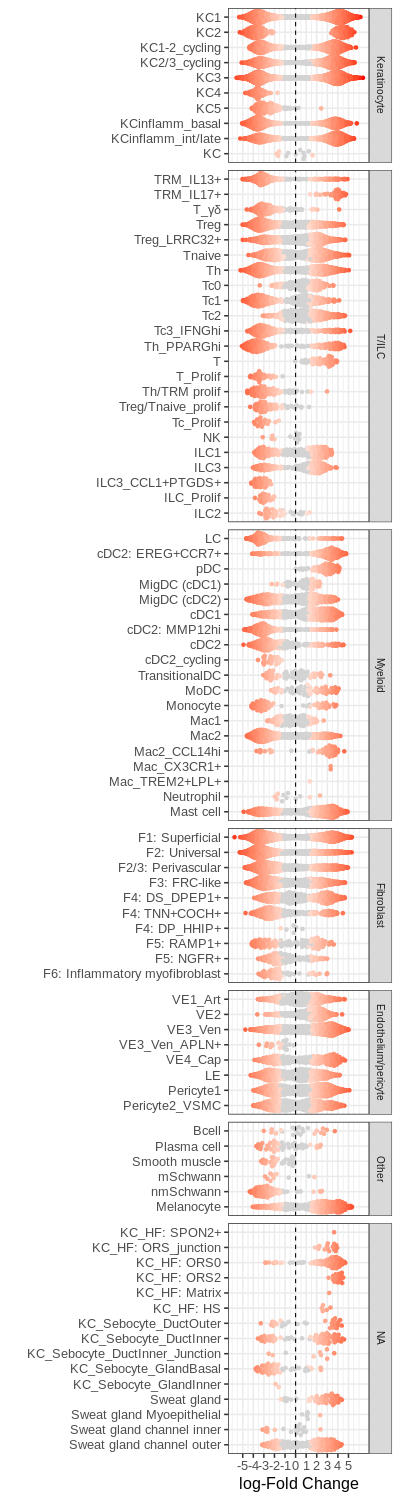

In [34]:
%%R -w 400 -h 1500

pl4 <- plot_df_copy %>% 
    mutate(is_signif = ifelse(SpatialFDR < 0.1, 1, 0)) %>%
    mutate(logFC_color = ifelse(is_signif == 1, logFC, NA_real_)) %>%
    ggplot(aes(nhood_anno, logFC, color = logFC_color)) +
    # Use scale_color_gradient2 for continuous logFC values, and set non-significant values to light grey
    scale_color_gradient2(low = "red", mid = "white", high = "red", midpoint = 0, na.value = "lightgrey") +
    geom_quasirandom(alpha = 1) +
    facet_grid(anno_group ~ organ, scales = "free", space = "free_y") +
    coord_flip() +
    guides(color = "none", fill = "none") +
    geom_hline(yintercept = 0, linetype = 2) +
    theme_bw(base_size = 16) +
    xlab("") + ylab("log-Fold Change") +
    scale_y_continuous(breaks = seq(-5, 5, by = 1)) +
    theme(
        strip.text.x = element_blank(),  # Remove the title on top
        strip.text.y = element_text(size = 10),  # Smaller strip text size
        strip.background = element_rect(size = 0.5),  # Reduce strip box size
        panel.spacing = unit(0.5, "lines")  # Adjust space between panels
    )
    
ggsave(
  filename = "milo_plots.pdf",
  plot = pl4,
  device = cairo_pdf,   # good for vector PDF output
  width = 7,            # in inches, adjust to taste
  height = 15,          # in inches
  dpi = 300
)
pl4

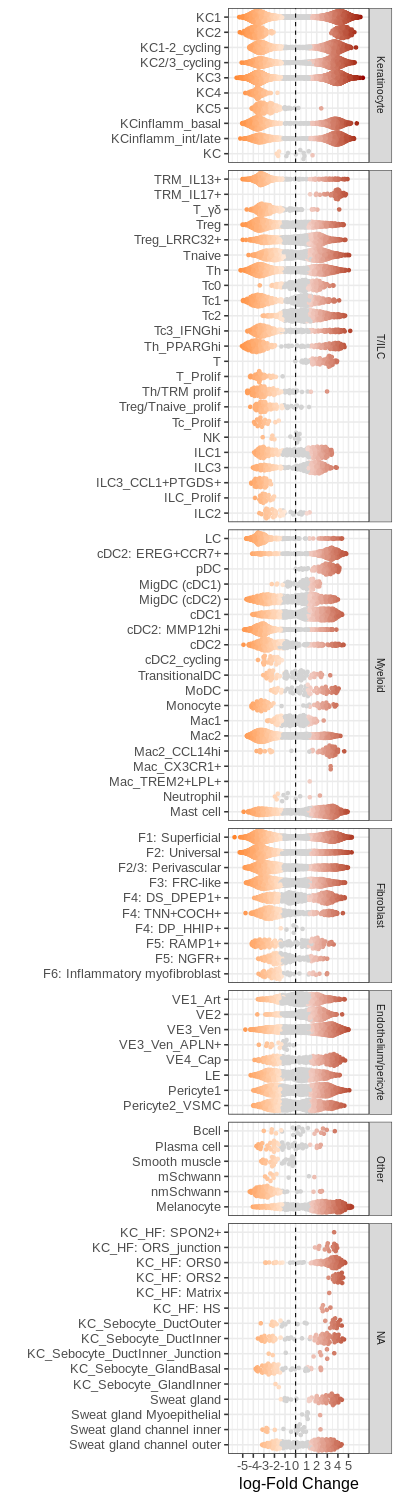

In [35]:
%%R -w 400 -h 1500

pl4 <- plot_df_copy %>% 
    mutate(is_signif = ifelse(SpatialFDR < 0.1, 1, 0)) %>%
    mutate(logFC_color = ifelse(is_signif == 1, logFC, NA_real_)) %>%
    ggplot(aes(nhood_anno, logFC, color = logFC_color)) +
    # Use scale_color_gradient2 for continuous logFC values, and set non-significant values to light grey
    scale_color_gradient2(low = "#ff7602", mid = "white", high = "#980000", midpoint = 0, na.value = "lightgrey") +
    geom_quasirandom(alpha = 1) +
    facet_grid(anno_group ~ organ, scales = "free", space = "free_y") +
    coord_flip() +
    guides(color = "none", fill = "none") +
    geom_hline(yintercept = 0, linetype = 2) +
    theme_bw(base_size = 16) +
    xlab("") + ylab("log-Fold Change") +
    scale_y_continuous(breaks = seq(-5, 5, by = 1)) +
    theme(
        strip.text.x = element_blank(),  # Remove the title on top
        strip.text.y = element_text(size = 10),  # Smaller strip text size
        strip.background = element_rect(size = 0.5),  # Reduce strip box size
        panel.spacing = unit(0.5, "lines")  # Adjust space between panels
    )
    
ggsave(
  filename = "milo_plots_diffcolors.pdf",
  plot = pl4,
  device = cairo_pdf,   # good for vector PDF output
  width = 7,            # in inches, adjust to taste
  height = 15,          # in inches
  dpi = 300
)
pl4